# Modelagem Preditiva de Churn — Plataforma de Streaming
> **Nota sobre o Desempenho dos Modelos:**
> 
> A acurácia excepcionalmente elevada alcançada pelos modelos (com o **Random Forest atingindo 99,2% de acurácia** e **AUC-ROC de 0.999**) deve ser interpretada com cautela em um contexto de negócio real.
> 
> Como mapeado na etapa de Análise Exploratória (EDA), o dataset de streaming possui indícios fortes de **geração sintética de dados**. Isso criou regras determinísticas e divisões rígidas na base — como clientes com `Satisfaction_Score` entre 1 e 3 ou com $\ge 5$ tickets de suporte apresentando exatamente **100% de taxa de cancelamento**. 
> 
> Os algoritmos baseados em árvores de decisão capturam essas regras com facilidade e quase sem ruído, o que justifica a performance próxima da perfeição. Em bases de dados de produção reais (comportamentais e com mais ruído estatístico), o comportamento esperado envolveria uma sobreposição maior entre as classes e métricas mais moderadas.

## Importações

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    roc_auc_score, roc_curve
)

## Carregando os dados

In [2]:
df = pd.read_csv('../data/churn_tratado.csv')
print(df.shape)
df.head()

(5000, 19)


,Customer_ID,Age,Gender,Subscription_Length,Region,Payment_Method,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Churned,Faixa_Subscription,Faixa_Monthly_Spend,Faixa_Discount,Faixa_Age,Faixa_Last_Activity,Faixa_Tickets,Faixa_Gasto
0,CUST000001,56.0,Male,54,South,PayPal,0,9.0,6.42,319,62.11,1,Maior,Maior,Menor,Mais velhos ainda,Maior,0 a 4 tickets,Acima de 60
1,CUST000002,69.0,Female,21,East,Debit Card,1,2.0,13.77,166,37.27,1,Baixo-médio,Menor,Alto-médio,Mais velhos ainda,Baixo-médio,0 a 4 tickets,30–40
2,CUST000003,46.0,Female,49,East,PayPal,3,8.0,19.91,207,61.82,0,Maior,Maior,Maior,Mais velhos,Alto-médio,0 a 4 tickets,Acima de 60
3,CUST000004,32.0,Male,47,West,Debit Card,3,1.0,13.39,108,40.96,1,Maior,Baixo-médio,Alto-médio,Mais jovens,Baixo-médio,0 a 4 tickets,40–50
4,CUST000005,60.0,Male,6,East,Credit Card,2,6.0,13.18,65,45.97,0,Menor,Baixo-médio,Alto-médio,Mais velhos ainda,Menor,0 a 4 tickets,40–50


## Listando as colunas e decidindo o que entra no modelo

In [3]:
df.dtypes

Customer_ID                object
Age                       float64
Gender                     object
Subscription_Length         int64
Region                     object
Payment_Method             object
Support_Tickets_Raised      int64
Satisfaction_Score        float64
Discount_Offered          float64
Last_Activity               int64
Monthly_Spend             float64
Churned                     int64
Faixa_Subscription         object
Faixa_Monthly_Spend        object
Faixa_Discount             object
Faixa_Age                  object
Faixa_Last_Activity        object
Faixa_Tickets              object
Faixa_Gasto                object
dtype: object

## Separando features (X) e alvo (y)

In [4]:
colunas_numericas = ['Age', 'Subscription_Length', 'Support_Tickets_Raised', 
                      'Satisfaction_Score', 'Discount_Offered', 'Last_Activity', 
                      'Monthly_Spend']

colunas_categoricas = ['Gender', 'Region', 'Payment_Method']

features = colunas_numericas + colunas_categoricas

X = df[features]
y = df['Churned']

print(X.shape)
print(y.value_counts())

(5000, 10)
Churned
0    2760
1    2240
Name: count, dtype: int64


## Dividindo em treino e teste

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

print('Treino:', X_train.shape)
print('Teste:', X_test.shape)
print()
print('Proporção treino:')
print(y_train.value_counts(normalize=True))
print()
print('Proporção teste:')
print(y_test.value_counts(normalize=True))

Treino: (4000, 10)
Teste: (1000, 10)

Proporção treino:
Churned
0    0.552
1    0.448
Name: proportion, dtype: float64

Proporção teste:
Churned
0    0.552
1    0.448
Name: proportion, dtype: float64


## Converter colunas categóricas em números (encoding)

In [6]:
encoder = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
encoder.fit(X_train[colunas_categoricas])


train_encoded_cat = pd.DataFrame(
    encoder.transform(X_train[colunas_categoricas]),
    columns=encoder.get_feature_names_out(colunas_categoricas),
    index=X_train.index
)
test_encoded_cat = pd.DataFrame(
    encoder.transform(X_test[colunas_categoricas]),
    columns=encoder.get_feature_names_out(colunas_categoricas),
    index=X_test.index
)


X_train_encoded = pd.concat([X_train[colunas_numericas], train_encoded_cat], axis=1)
X_test_encoded = pd.concat([X_test[colunas_numericas], test_encoded_cat], axis=1)

print(X_train_encoded.shape)
X_train_encoded.head()

(4000, 13)


,Age,Subscription_Length,Support_Tickets_Raised,Satisfaction_Score,Discount_Offered,Last_Activity,Monthly_Spend,Gender_Male,Region_North,Region_South,Region_West,Payment_Method_Debit Card,Payment_Method_PayPal
100,62.0,24,1,8.0,19.90,294,56.35,1.0,0.0,0.0,0.0,0.0,1.0
2330,57.0,9,2,6.0,14.25,195,42.38,1.0,0.0,0.0,1.0,1.0,0.0
1112,40.0,46,5,6.0,5.33,173,45.90,0.0,0.0,0.0,1.0,1.0,0.0
1644,69.0,38,1,3.0,11.97,47,45.17,1.0,0.0,0.0,1.0,0.0,1.0
345,50.0,56,5,9.0,16.25,155,62.50,0.0,0.0,0.0,0.0,1.0,0.0


## Treinando o primeiro modelo (Regressão Logística)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)


modelo_lr = LogisticRegression(max_iter=1000, random_state=42)
modelo_lr.fit(X_train_scaled, y_train)

print('Modelo treinado com sucesso')

Modelo treinado com sucesso


## Avaliando o modelo nos dados de teste

In [8]:
y_pred = modelo_lr.predict(X_test_scaled)

print('Acurácia:', accuracy_score(y_test, y_pred))
print()
print('Matriz de confusão:')
print(confusion_matrix(y_test, y_pred))
print()
print('Relatório completo:')
print(classification_report(y_test, y_pred))

Acurácia: 0.808

Matriz de confusão:
[[466  86]
 [106 342]]

Relatório completo:
              precision    recall  f1-score   support

           0       0.81      0.84      0.83       552
           1       0.80      0.76      0.78       448

    accuracy                           0.81      1000
   macro avg       0.81      0.80      0.81      1000
weighted avg       0.81      0.81      0.81      1000



## Vendo quais variáveis mais influenciam o modelo

In [9]:
coeficientes = pd.DataFrame({
    'variavel': X_train_encoded.columns,
    'coeficiente': modelo_lr.coef_[0]
})

coeficientes['peso_absoluto'] = coeficientes['coeficiente'].abs()
coeficientes = coeficientes.sort_values('peso_absoluto', ascending=False)

print(coeficientes)

                     variavel  coeficiente  peso_absoluto
6               Monthly_Spend    -1.680548       1.680548
5               Last_Activity     1.305591       1.305591
1         Subscription_Length     0.955850       0.955850
3          Satisfaction_Score    -0.684664       0.684664
4            Discount_Offered     0.368673       0.368673
2      Support_Tickets_Raised     0.337815       0.337815
12      Payment_Method_PayPal     0.139491       0.139491
11  Payment_Method_Debit Card     0.122132       0.122132
8                Region_North     0.090726       0.090726
10                Region_West     0.080104       0.080104
9                Region_South    -0.034699       0.034699
7                 Gender_Male     0.032126       0.032126
0                         Age     0.009093       0.009093


## Treinando um modelo de Random Forest

In [10]:
modelo_rf = RandomForestClassifier(n_estimators=100, random_state=42)

modelo_rf.fit(X_train_encoded, y_train)

y_pred_rf = modelo_rf.predict(X_test_encoded)
y_proba_rf = modelo_rf.predict_proba(X_test_encoded)[:, 1]

print("=== RESULTADOS RANDOM FOREST ===")
print("Acurácia:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred_rf))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred_rf))

=== RESULTADOS RANDOM FOREST ===
Acurácia: 0.992
ROC-AUC: 0.9997290696169772

Matriz de Confusão:
[[552   0]
 [  8 440]]

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       552
           1       1.00      0.98      0.99       448

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



## Importancia das variaveis no Random Forest (Feature Importance)

In [11]:
importancia_rf = pd.DataFrame({
    'variavel': X_train_encoded.columns,
    'importancia': modelo_rf.feature_importances_
}).sort_values('importancia', ascending=False)

print("=== IMPORTÂNCIA DAS VARIÁVEIS (RANDOM FOREST) ===")
print(importancia_rf)

=== IMPORTÂNCIA DAS VARIÁVEIS (RANDOM FOREST) ===
                     variavel  importancia
3          Satisfaction_Score     0.364685
5               Last_Activity     0.318056
6               Monthly_Spend     0.140854
2      Support_Tickets_Raised     0.097733
1         Subscription_Length     0.032424
4            Discount_Offered     0.021072
0                         Age     0.013019
7                 Gender_Male     0.002424
11  Payment_Method_Debit Card     0.002211
8                Region_North     0.002067
12      Payment_Method_PayPal     0.002037
9                Region_South     0.001788
10                Region_West     0.001631


## Comparação direta entre Regressão Logística e Random Forest

In [12]:
y_proba_lr = modelo_lr.predict_proba(X_test_scaled)[:, 1]

comparativo = pd.DataFrame({
    'Métrica': ['Acurácia', 'ROC-AUC Score'],
    'Regressão Logística': [
        accuracy_score(y_test, y_pred), 
        roc_auc_score(y_test, y_proba_lr)
    ],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf), 
        roc_auc_score(y_test, y_proba_rf)
    ]
})

print("=== COMPARATIVO DIRETO ===")
print(comparativo)

=== COMPARATIVO DIRETO ===
         Métrica  Regressão Logística  Random Forest
0       Acurácia             0.808000       0.992000
1  ROC-AUC Score             0.900047       0.999729


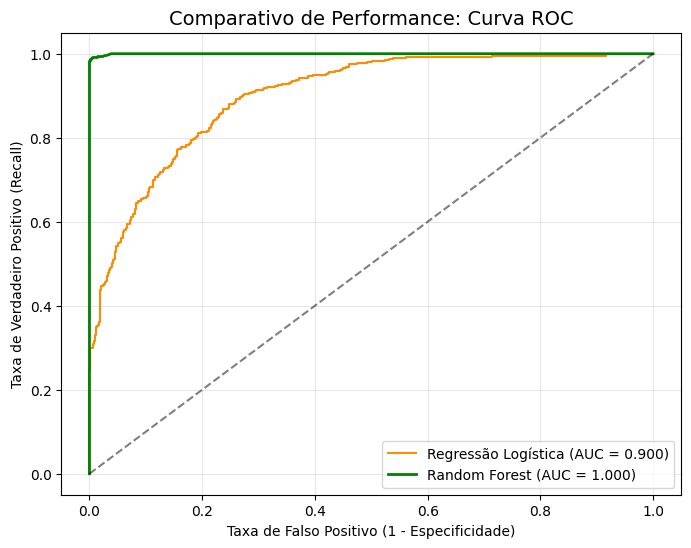

In [13]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, label=f'Regressão Logística (AUC = {comparativo.loc[1, "Regressão Logística"]:.3f})', color='darkorange')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {comparativo.loc[1, "Random Forest"]:.3f})', color='green', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', alpha=0.5)

plt.title('Comparativo de Performance: Curva ROC', fontsize=14)
plt.xlabel('Taxa de Falso Positivo (1 - Especificidade)')
plt.ylabel('Taxa de Verdadeiro Positivo (Recall)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

## Validação cruzada

In [14]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('modelo', LogisticRegression(max_iter=1000, random_state=42))
])

scores_lr = cross_val_score(
    pipeline_lr, X_train_encoded, y_train,
    cv=skf, scoring='roc_auc'
)

scores_rf = cross_val_score(
    modelo_rf.__class__(n_estimators=100, random_state=42),
    X_train_encoded, y_train,
    cv=skf, scoring='roc_auc'
)

print("=== VALIDAÇÃO CRUZADA (5 folds, métrica: ROC-AUC) ===\n")
print(f"Regressão Logística: {scores_lr.mean():.4f} (+/- {scores_lr.std():.4f})")
print(f"  Scores por fold: {np.round(scores_lr, 4)}")
print()
print(f"Random Forest:       {scores_rf.mean():.4f} (+/- {scores_rf.std():.4f})")
print(f"  Scores por fold: {np.round(scores_rf, 4)}")

=== VALIDAÇÃO CRUZADA (5 folds, métrica: ROC-AUC) ===

Regressão Logística: 0.8974 (+/- 0.0061)
  Scores por fold: [0.8997 0.9043 0.8867 0.9008 0.8953]

Random Forest:       0.9994 (+/- 0.0004)
  Scores por fold: [0.9999 0.9991 0.9989 0.9996 0.9993]


In [15]:
os.makedirs('../models', exist_ok=True)

pipeline_final = Pipeline([
    ('scaler', scaler),
    ('modelo', modelo_lr)
])

caminho_modelo = '../models/modelo_churn_lr.joblib'
joblib.dump(pipeline_final, caminho_modelo)
print(f"Modelo salvo com sucesso em: {caminho_modelo}")

novo_cliente = pd.DataFrame([{
    'Age': 45.0,
    'Subscription_Length': 12,
    'Support_Tickets_Raised': 5, 
    'Satisfaction_Score': 2.0,
    'Discount_Offered': 10.0,
    'Last_Activity': 180,
    'Monthly_Spend': 28.00,   
    'Gender_Male': False,
    'Region_North': True,
    'Region_South': False,
    'Region_West': False,
    'Payment_Method_Debit Card': False,
    'Payment_Method_PayPal': True
}])

modelo_carregado = joblib.load(caminho_modelo)
probabilidade = modelo_carregado.predict_proba(novo_cliente)[0][1]
predicao = modelo_carregado.predict(novo_cliente)[0]

limite_inatividade = X_train_encoded['Last_Activity'].quantile(0.75)


acoes_recomendadas = []

if novo_cliente['Support_Tickets_Raised'].iloc[0] >= 5:
    acoes_recomendadas.append(
        "Suporte: investigar as causas dos chamados e criar acompanhamento "
        "proativo (cliente com 5+ tickets registrados)."
    )

if novo_cliente['Last_Activity'].iloc[0] >= limite_inatividade:
    acoes_recomendadas.append(
        f"Reengajamento: acionar campanha com novidades e recomendações do "
        f"catálogo (inatividade de {novo_cliente['Last_Activity'].iloc[0]:.0f} dias, "
        f"acima do limiar de risco de {limite_inatividade:.0f} dias)."
    )

if 1 <= novo_cliente['Satisfaction_Score'].iloc[0] <= 3:
    acoes_recomendadas.append(
        "Satisfação: identificar as causas-raiz associadas à avaliação baixa "
        "e atuar diretamente nesses pontos da experiência."
    )

if novo_cliente['Monthly_Spend'].iloc[0] <= 30:
    acoes_recomendadas.append(
        "Planos de Entrada: avaliar o onboarding e a proposta de valor do "
        "plano atual (gasto mensal ≤ $30)."
    )

print("\n=== RESULTADO DA SIMULAÇÃO ===")
print(f"Predição Final: {'CANCELAMENTO (Churn)' if predicao == 1 else 'RETENÇÃO (Permanece)'}")
print(f"Probabilidade de Churn: {probabilidade:.1%}")

if acoes_recomendadas:
    print(f"\nAções Recomendadas ({len(acoes_recomendadas)} fator(es) de risco identificado(s)):")
    for acao in acoes_recomendadas:
        print(f"  {acao}")
else:
    print("\nNenhum fator de risco crítico identificado — manter fluxo padrão de acompanhamento.")

Modelo salvo com sucesso em: ../models/modelo_churn_lr.joblib

=== RESULTADO DA SIMULAÇÃO ===
Predição Final: CANCELAMENTO (Churn)
Probabilidade de Churn: 97.1%

Ações Recomendadas (3 fator(es) de risco identificado(s)):
  Suporte: investigar as causas dos chamados e criar acompanhamento proativo (cliente com 5+ tickets registrados).
  Satisfação: identificar as causas-raiz associadas à avaliação baixa e atuar diretamente nesses pontos da experiência.
  Planos de Entrada: avaliar o onboarding e a proposta de valor do plano atual (gasto mensal ≤ $30).


## Conclusão e escolha do modelo

### Comparativo final

| Modelo | Acurácia (teste) | ROC-AUC (teste) | ROC-AUC (CV, 5 folds) |
|---|---|---|---|
| Regressão Logística | 80.8% | 0.900 | 0.897 (±0.006) |
| Random Forest | 99.2% | 0.9997 | 0.999 (±0.0004) |

### Por que a Regressão Logística foi escolhida como modelo final

Apesar do Random Forest apresentar métricas superiores neste dataset, a validação 
cruzada confirmou baixíssima variância entre folds em ambos os modelos — evidência de 
que a performance quase perfeita do RF não é fruto de um split favorável, e sim de 
padrões determinísticos já identificados na EDA (ex: `Satisfaction_Score` entre 1 e 3 
e `Support_Tickets_Raised` ≥ 5 correspondendo a 100% de churn na base).

Isso significa que o Random Forest está aprendendo regras artificiais do dataset 
sintético, não relações que necessariamente se sustentariam em dados reais de produção. 
A Regressão Logística, com AUC ~0.90, é uma estimativa mais conservadora e mais 
representativa do que se esperaria em um cenário com mais ruído estatístico.

### O que os coeficientes da Regressão Logística revelam sobre o negócio

Olhando os pesos absolutos mais relevantes:

- **`Monthly_Spend` (coef. -1.68):** o fator de maior peso no modelo. Quanto menor o 
  gasto mensal, maior a chance de churn — confirma o insight já levantado na EDA.
- **`Last_Activity` (coef. +1.31):** quanto mais dias desde a última atividade, maior 
  a chance de churn — reforça a importância de monitorar inatividade como sinal de risco.
- **`Subscription_Length` (coef. +0.96):** contra-intuitivamente, tempo de assinatura 
  mais longo está associado a maior risco de churn no modelo linear. Vale investigar 
  esse padrão com mais profundidade antes de usá-lo isoladamente em decisões de negócio.
- **`Satisfaction_Score` (coef. -0.68):** confirma que maior satisfação reduz a 
  probabilidade de cancelamento, como já mapeado na EDA.
